# Visualisasi Data Berdimensi Tinggi Menggunakan Principal Component Analysis (PCA)

---

Unsupervised Learning  
**Metode:** Principal Component Analysis (PCA) 

## Deskripsi
Mengurangi dimensi data kompleks agar lebih mudah divisualisasikan dan dianalisis menggunakan PCA.

## Tujuan
1. Memahami konsep dimensionality reduction menggunakan PCA
2. Mengimplementasi PCA pada dataset Digits(64 fitur)
3. Memvisualisasikan hasil reduksi dimensi dalam 2D dan 3D
4. Menganalisis dan menginterpretasikan hasil PCA

## Dataset

Untuk dataset digits 64 fitur (8x8pixel) dengan 10 angka (0 - 9), saya mengambil sumber langsung dari sklearn.dataset.load_digits.
Ini adalah dataset yang sudah disediakan langsung dari library python untuk keperluan pembelajaran.

# Import Library

In [2]:
# Standard library
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Dataset
from sklearn.datasets import load_digits

# Prepocessing dan PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Static Vsiualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Interactive Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
COLORS = plt.cm.tab10.colors

## Load Dataset

Load dataset dari library sklearn.dataset

In [ ]:
# Digits Dataset
digits = load_digits()
X = digits.data   # fitur atau variabel independen (shape: 1797, 64)
y = digits.target  # label atau variabel dependen (label angka 0-9, shape: 1797)

print(f'   Shape  : {X.shape}  →  {X.shape[0]} sampel, {X.shape[1]} fitur')
print(f'   Kelas  : {digits.target_names}')
print(f'   Type   : {X.dtype}')


   Shape  : (1797, 64)  →  1797 sampel, 64 fitur
   Kelas  : [0 1 2 3 4 5 6 7 8 9]
   Type   : float64


## Exploratory Data Analysis (EDA)
Pahami struktur data terlebih dahulu.

In [4]:
df_dig = pd.DataFrame(X, columns=[f'pixel_{i}' for i in range(X.shape[1])])
df_dig['label'] = y

print('Statistik Deskriptif:')
print(df_dig.describe().round(2).to_string())
print()
print('Distribusi Kelas:')
print(df_dig['label'].value_counts().sort_index())

Statistik Deskriptif:
       pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  pixel_8  pixel_9  pixel_10  pixel_11  pixel_12  pixel_13  pixel_14  pixel_15  pixel_16  pixel_17  pixel_18  pixel_19  pixel_20  pixel_21  pixel_22  pixel_23  pixel_24  pixel_25  pixel_26  pixel_27  pixel_28  pixel_29  pixel_30  pixel_31  pixel_32  pixel_33  pixel_34  pixel_35  pixel_36  pixel_37  pixel_38  pixel_39  pixel_40  pixel_41  pixel_42  pixel_43  pixel_44  pixel_45  pixel_46  pixel_47  pixel_48  pixel_49  pixel_50  pixel_51  pixel_52  pixel_53  pixel_54  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  pixel_60  pixel_61  pixel_62  pixel_63    label
count   1797.0  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00  1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00   1797.00    1797.0   1797.

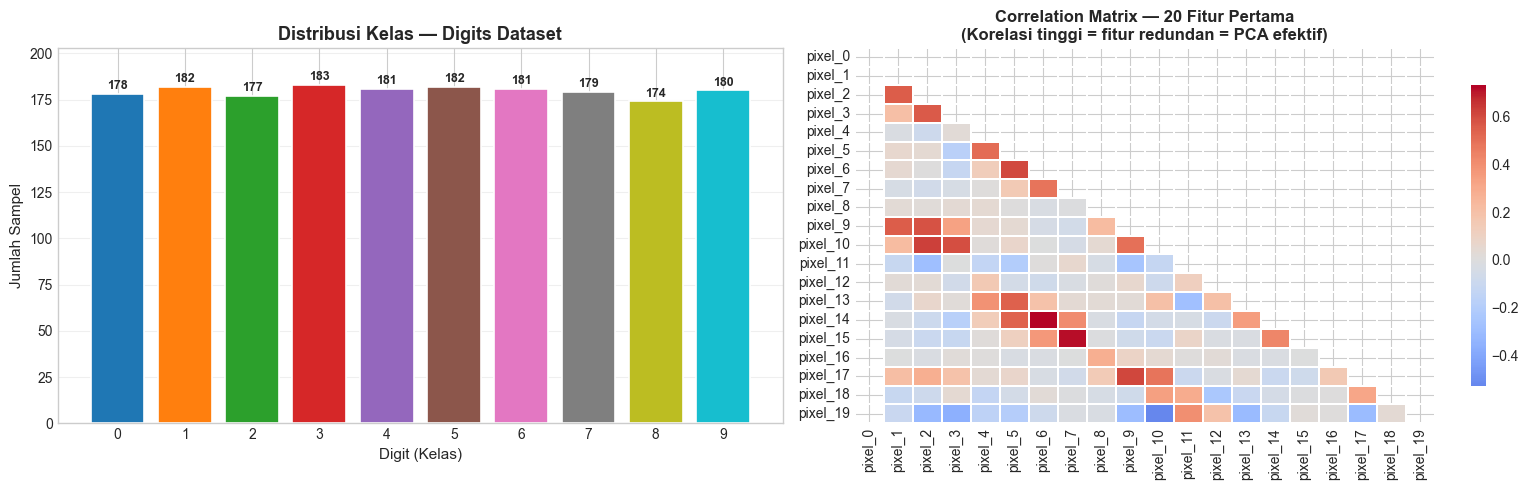

 Insight:
   - Distribusi kelas sangat seimbang: 174–183 sampel per kelas
   - Banyak piksel berkorelasi tinggi → informasi redundan → PCA akan efektif


In [ ]:
# Distribusi Kelas & Heatmap Korelasi 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KIRI: Bar chart distribusi kelas 
class_counts = pd.Series(y).value_counts().sort_index()
bars = axes[0].bar(class_counts.index, class_counts.values,
                   color=plt.cm.tab10.colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Kelas — Digits Dataset', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Digit (Kelas)', fontsize=11)
axes[0].set_ylabel('Jumlah Sampel', fontsize=11)
axes[0].set_xticks(range(10))

# Tambahkan angka di atas tiap bar
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

axes[0].set_ylim(0, class_counts.max() + 20)
axes[0].grid(axis='y', alpha=0.3)

# KANAN: Heatmap korelasi (20 fitur pertama)
corr = df_dig.iloc[:, :20].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # sembunyikan segitiga atas (duplikat)

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3,
            ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlation Matrix — 20 Fitur Pertama\n'
                  '(Korelasi tinggi = fitur redundan = PCA efektif)',
                  fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('eda_distribusi_korelasi.png', dpi=120, bbox_inches='tight')
plt.show()

print(' Insight:')
print(f'   - Distribusi kelas sangat seimbang: {class_counts.min()}–{class_counts.max()} sampel per kelas')
print('   - Banyak piksel berkorelasi tinggi → informasi redundan → PCA akan efektif')

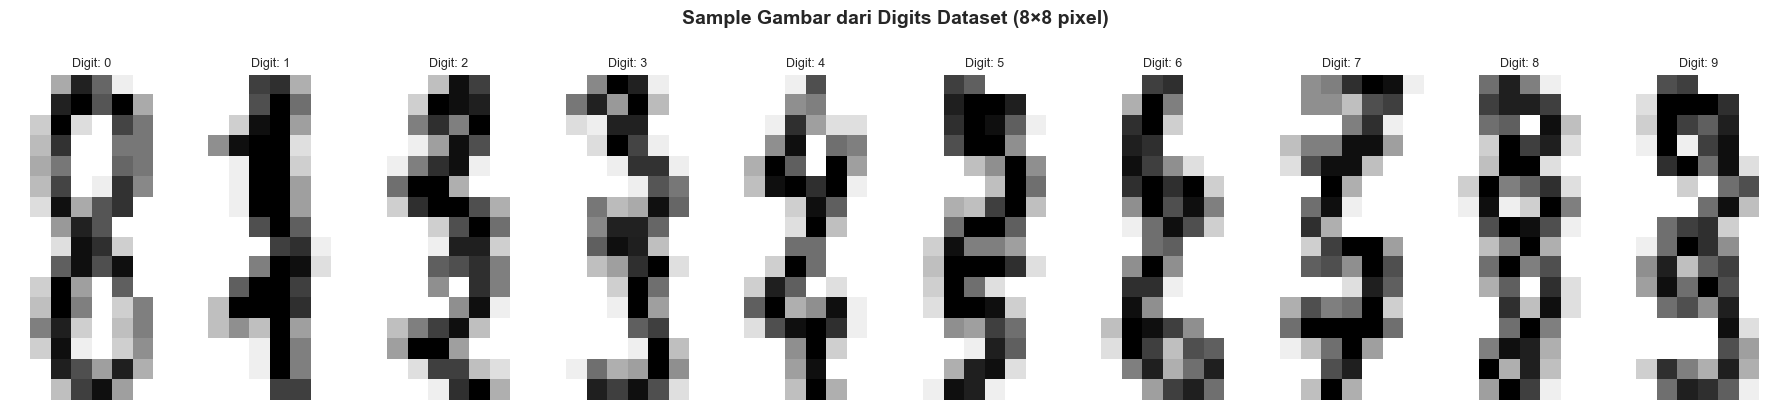

Setiap gambar memiliki 64 fitur (8×8=64 piksel) yang akan direduksi ke 2D


In [5]:
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('Sample Gambar dari Digits Dataset (8×8 pixel)', fontsize=14, fontweight='bold', y=1.02)

for digit in range(10):
    # ambil satu sample per kelas
    idx = np.where(y == digit)[0][0]
    axes[0, digit].imshow(X[idx].reshape(8, 8), cmap='gray_r')
    axes[0, digit].set_title(f'Digit: {digit}', fontsize=9)
    axes[0, digit].axis('off')
    
    idx2 = np.where(y == digit)[0][5]
    axes[1, digit].imshow(X[idx2].reshape(8, 8), cmap='gray_r')
    axes[1, digit].axis('off')

plt.tight_layout()
plt.savefig('sample_digits.png', dpi=120, bbox_inches='tight')
plt.show()
print('Setiap gambar memiliki 64 fitur (8×8=64 piksel) yang akan direduksi ke 2D')

## Preprocessing dan StandardScaler

Ini sangat penting karena PCA itu sensitif terhadap skala fitur. Jika ada fitur dengan nilai lebih besar maka ia akan mendominasi principal component. Maka dari itu kita butuh menormalisasikan nilai dari setiap fitur agar tidak ada kesenjangan nilai yang begitu jauh. Juga mengubah setiap fitur agar memiliki nilai mean=0 dan std=1.

In [6]:
scaler = StandardScaler()

# Standarisasi fitur
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('StandardScaler diterapkan pada dataset')
print()
print('SEBELUM scaling (fitur ke-3):')
print(f'  Mean : {X[:, 2].mean():.4f}')
print(f'  Std  : {X[:, 2].std():.4f}')
print(f'  Min  : {X[:, 2].min():.4f}')
print(f'  Max  : {X[:, 2].max():.4f}')
print()
print('SESUDAH scaling (fitur ke-3):')
print(f'  Mean : {X_scaled[:, 2].mean():.6f}')
print(f'  Std  : {X_scaled[:, 2].std():.6f}')
print(f'  Min  : {X_scaled[:, 2].min():.4f}')
print(f'  Max  : {X_scaled[:, 2].max():.4f}')


StandardScaler diterapkan pada dataset

SEBELUM scaling (fitur ke-3):
  Mean : 5.2048
  Std  : 4.7535
  Min  : 0.0000
  Max  : 16.0000

SESUDAH scaling (fitur ke-3):
  Mean : 0.000000
  Std  : 1.000000
  Min  : -1.0949
  Max  : 2.2710


## Menentukan Jumlah Komponen Optimal - Scree Plot
Bagian ini bertujuan untuk menunjukan seberapa banyak principal component yang diperlukan untuk mempertahankan informasi (variance) yang cukup dari data asli.

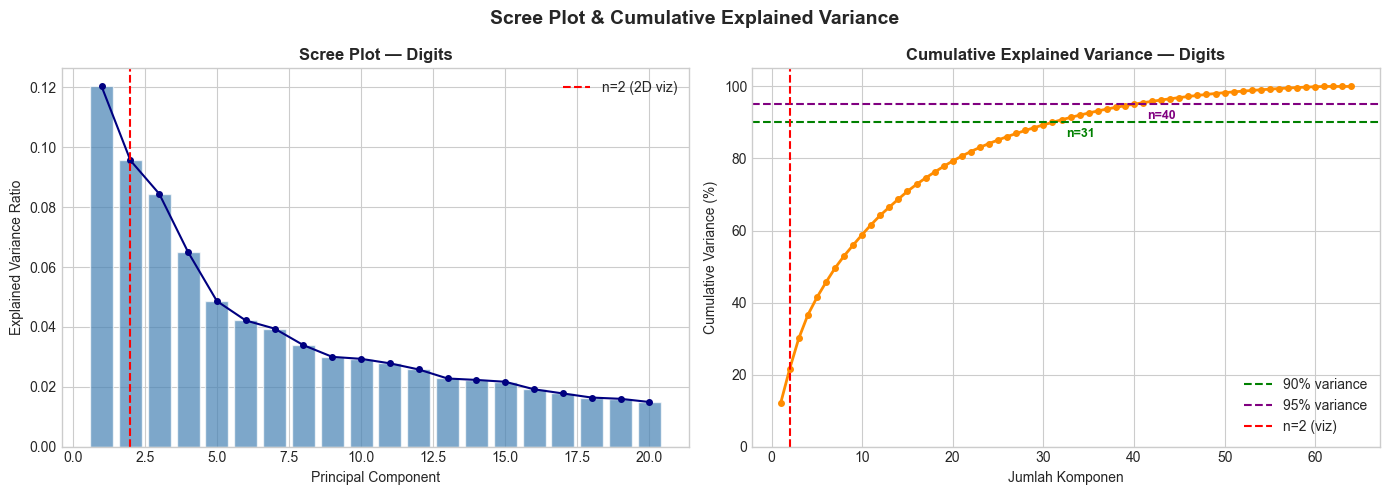

   PC1 + PC2 menjelaskan : 21.6% variance
   Butuh 31 PC untuk  : 90% variance
   Butuh 40 PC untuk  : 95% variance


In [14]:
# PCA (semua komponen)
pca_full = PCA().fit(X_scaled)

# Membuat 2 subplots untuk scree plot dan cumulative variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Scree Plot & Cumulative Explained Variance', fontsize=14, fontweight='bold')

evr  = pca_full.explained_variance_ratio_
cumr = np.cumsum(evr)
comps = np.arange(1, len(evr) + 1)

# Scree plot
ax = axes[0]
ax.bar(comps[:20], evr[:20], color='steelblue', alpha=0.7, edgecolor='white')
ax.plot(comps[:20], evr[:20], 'o-', color='navy', lw=1.5, ms=4)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot — Digits', fontweight='bold')
ax.axvline(x=2, color='red', ls='--', lw=1.5, label='n=2 (2D viz)')
ax.legend()

# Cumulative variance
ax2 = axes[1]
ax2.plot(comps, cumr * 100, 'o-', color='darkorange', lw=2, ms=4)
ax2.axhline(y=90, color='green',  ls='--', lw=1.5, label='90% variance')
ax2.axhline(y=95, color='purple', ls='--', lw=1.5, label='95% variance')
ax2.axvline(x=2, color='red',     ls='--', lw=1.5, label='n=2 (viz)')

# annotate
for pct, color in [(0.90, 'green'), (0.95, 'purple')]:
    n_needed = np.argmax(cumr >= pct) + 1
    ax2.annotate(f'n={n_needed}', xy=(n_needed, pct*100),
                xytext=(n_needed + 1.5, pct*100 - 4),
                color=color, fontsize=9, fontweight='bold')

ax2.set_xlabel('Jumlah Komponen')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance — Digits', fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('scree_plot.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary
evr  = pca_full.explained_variance_ratio_
cumr = np.cumsum(evr)
n90  = np.argmax(cumr >= 0.90) + 1
n95  = np.argmax(cumr >= 0.95) + 1
print(f'   PC1 + PC2 menjelaskan : {(evr[0]+evr[1])*100:.1f}% variance')
print(f'   Butuh {n90} PC untuk  : 90% variance')
print(f'   Butuh {n95} PC untuk  : 95% variance')


## Fit & Transform PCA (2D dan 3D)  

In [8]:
# 2D PCA 
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 3D PCA
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f'2D PCA shape: {X_pca_2d.shape}  →  {X_pca_2d.shape[0]} sampel, {X_pca_2d.shape[1]} fitur')
print(f'3D PCA shape: {X_pca_3d.shape}  →  {X_pca_3d.shape[0]} sampel, {X_pca_3d.shape[1]} fitur')

2D PCA shape: (1797, 2)  →  1797 sampel, 2 fitur
3D PCA shape: (1797, 3)  →  1797 sampel, 3 fitur


## Visualisasi 2D dan 3D

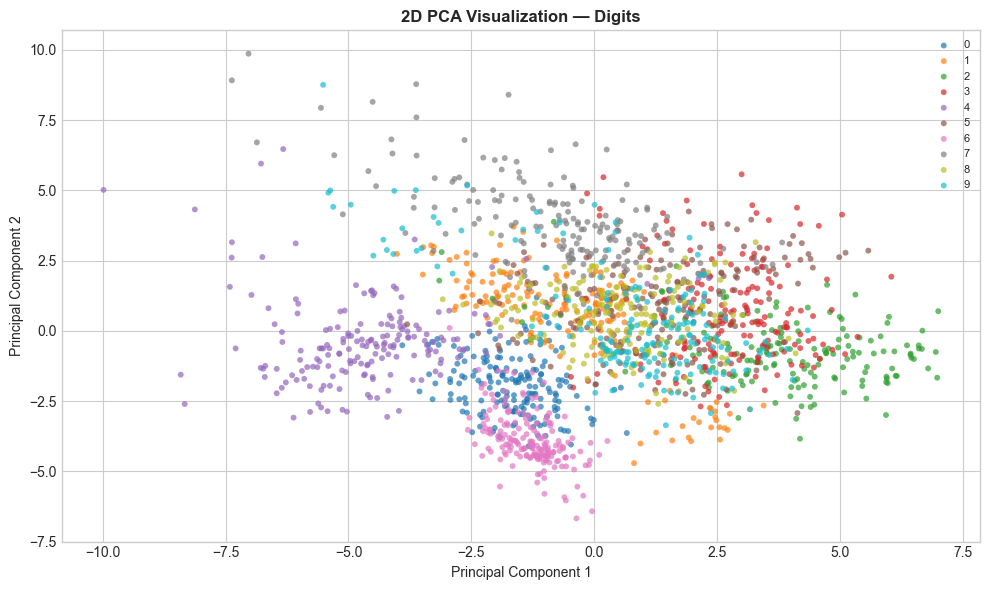

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

# 2D
for digit in range(10):
    mask = (y == digit)
    ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
        label=str(digit), alpha=0.7, s=18,
        color=COLORS[digit], edgecolors='none')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('2D PCA Visualization — Digits', fontweight='bold')
ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('pca_2d.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# 3D
df_3d_dig = pd.DataFrame(X_pca_3d, columns=['PC1', 'PC2', 'PC3'])
df_3d_dig['Digit'] = y.astype(str)

fig_3d_dig = px.scatter_3d(
    df_3d_dig, x='PC1', y='PC2', z='PC3', color='Digit',
    title=f'PCA 3D — Digits Dataset<br>'
          f'PC1={pca_3d.explained_variance_ratio_[0]*100:.1f}%, '
          f'PC2={pca_3d.explained_variance_ratio_[1]*100:.1f}%, '
          f'PC3={pca_3d.explained_variance_ratio_[2]*100:.1f}%',
    opacity=0.75,
    width=800, height=600
)
fig_3d_dig.update_traces(marker=dict(size=3))
fig_3d_dig.update_layout(legend_title_text='Digit')
fig_3d_dig.show()

## Biplot
Menampilkan posisi sampel dalam ruang PCA (score plot) dan arag kontribusi setiap fitur terhadap principal component (loading plot).

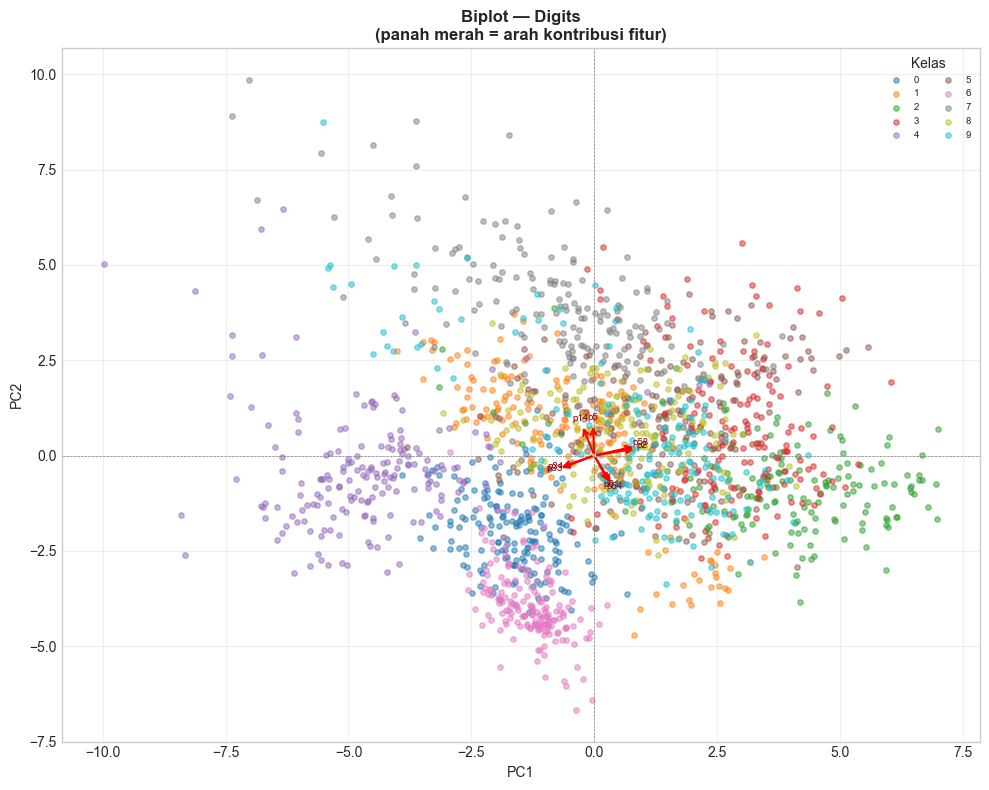

Fitur dengan panah panjang = kontribusi besar ke PC tersebut.
Fitur dengan arah panah yang sama = berkorelasi positif.


In [11]:
def biplot(score, loading, labels, feature_names, title, ax, n_arrows=8):
    """
    Biplot: tampilkan score sampel + loading vektor fitur.
    Hanya tampilkan n_arrows fitur dengan loading terbesar.
    """
    xs = score[:, 0]
    ys = score[:, 1]
    unique_labels = np.unique(labels)

    for i, lab in enumerate(unique_labels):
        mask = labels == lab
        ax.scatter(xs[mask], ys[mask], alpha=0.5, s=15,
                   label=str(lab), color=COLORS[i % 10], zorder=1)

    # Pilih n_arrows fitur dengan magnitude loading terbesar
    magnitudes = np.sqrt(loading[:, 0]**2 + loading[:, 1]**2)
    top_idx    = np.argsort(magnitudes)[::-1][:n_arrows]

    scale = 3.0
    for idx in top_idx:
        lx, ly = loading[idx, 0] * scale, loading[idx, 1] * scale
        ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color='red', lw=1.5), zorder=3)
        ax.text(lx * 1.12, ly * 1.12, feature_names[idx],
                color='darkred', fontsize=7, ha='center', zorder=4)

    ax.set_xlabel('PC1', fontsize=10)
    ax.set_ylabel('PC2', fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, ncol=2, title='Kelas')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.axvline(0, color='gray', lw=0.5, ls='--')


fig, ax = plt.subplots(figsize=(10, 8))

biplot(X_pca_2d, pca_2d.components_.T,
       y, [f'p{i}' for i in range(64)],
       'Biplot — Digits\n(panah merah = arah kontribusi fitur)',
       ax, n_arrows=8)

plt.tight_layout()
plt.savefig('biplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Fitur dengan panah panjang = kontribusi besar ke PC tersebut.')
print('Fitur dengan arah panah yang sama = berkorelasi positif.')

## Rekonstruksi Gambar


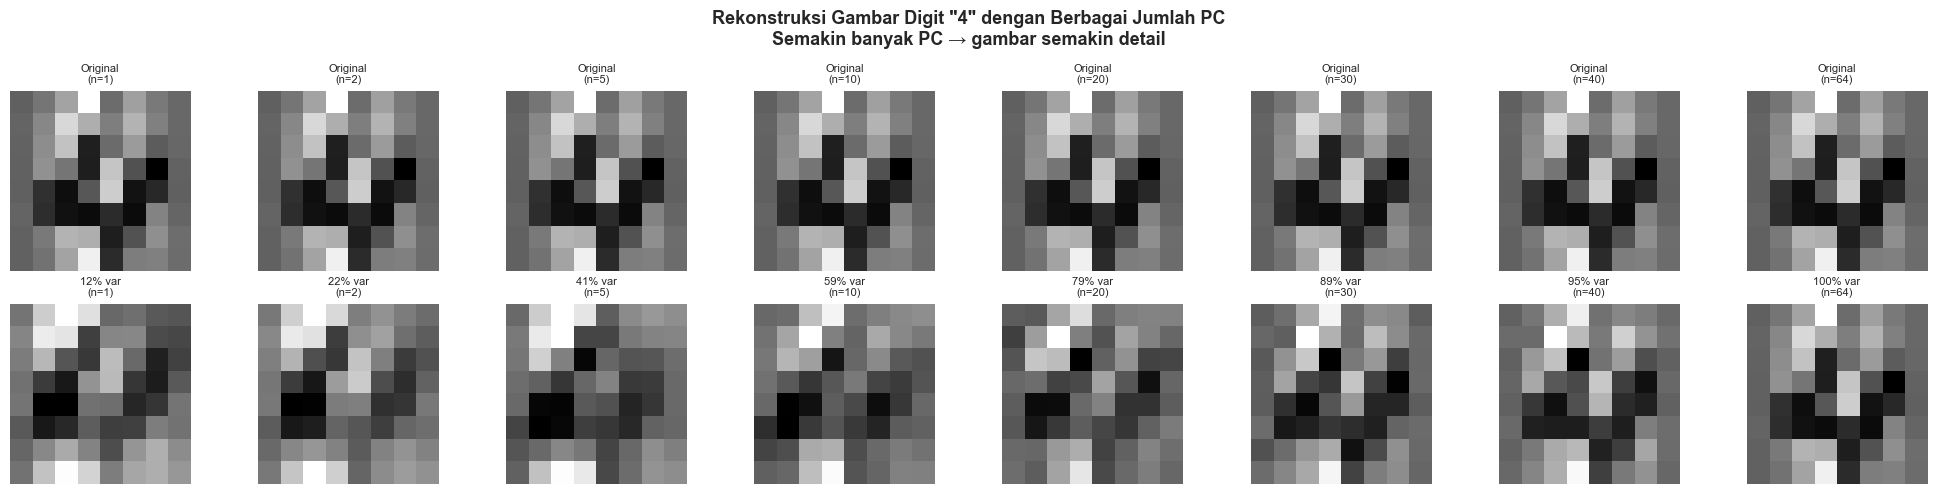

🔑 KEY INSIGHT: Dengan hanya 10 PC (dari 64), gambar sudah dapat dikenali!
   Ini membuktikan sebagian besar informasi tersimpan di sedikit komponen utama.


In [21]:
n_components_list = [1, 2, 5, 10, 20, 30, 40, 64]

digit_to_show = 4
sample_idx = np.where(y == digit_to_show)[0][0]  # Ambil sample pertama dari digit tersebut

fig, axes = plt.subplots(2, len(n_components_list), figsize=(20, 5))
fig.suptitle(f'Rekonstruksi Gambar Digit "{y[sample_idx]}" dengan Berbagai Jumlah PC\n'
             'Semakin banyak PC → gambar semakin detail', fontsize=13, fontweight='bold')

for i, n in enumerate(n_components_list):
    pca_n = PCA(n_components=n, random_state=42)
    X_reduced   = pca_n.fit_transform(X_scaled)
    X_reconstructed = pca_n.inverse_transform(X_reduced)

    var_explained = pca_n.explained_variance_ratio_.sum() * 100

    # Row 0: gambar asli sample
    axes[0, i].imshow(X_scaled[sample_idx].reshape(8, 8), cmap='gray_r')
    axes[0, i].set_title(f'Original\n(n={n})', fontsize=8)
    axes[0, i].axis('off')

    # Row 1: hasil rekonstruksi
    axes[1, i].imshow(X_reconstructed[sample_idx].reshape(8, 8), cmap='gray_r')
    axes[1, i].set_title(f'{var_explained:.0f}% var\n(n={n})', fontsize=8)
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig('reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()
print('🔑 KEY INSIGHT: Dengan hanya 10 PC (dari 64), gambar sudah dapat dikenali!')
print('   Ini membuktikan sebagian besar informasi tersimpan di sedikit komponen utama.')

### Ringkasan Data Hasil PCA
 

In [13]:
print('DIGITS DATASET (784 fitur → sebenarnya 64, 10 kelas)')
print(f'   PC1 + PC2 mempertahankan : {pca_2d.explained_variance_ratio_.sum()*100:.1f}% informasi')
print(f'   PC1 + PC2 + PC3          : {pca_3d.explained_variance_ratio_.sum()*100:.1f}% informasi')
print('   Cluster 10 digit terlihat terpisah di ruang 2D/3D')
print('   Rekonstruksi dengan 10 PC sudah menampilkan gambar yang dapat dikenali')


DIGITS DATASET (784 fitur → sebenarnya 64, 10 kelas)
   PC1 + PC2 mempertahankan : 21.6% informasi
   PC1 + PC2 + PC3          : 30.0% informasi
   Cluster 10 digit terlihat terpisah di ruang 2D/3D
   Rekonstruksi dengan 10 PC sudah menampilkan gambar yang dapat dikenali


## Kesimpulan

- PCA berhasil mereduksi data dari 64 dimensi menjadi 2 dimensi sambil mempertahankan struktur kemiripan antar kelas
- Hanya dengan 10 principal component (15.6% dari total), gambar angka sudah dapat dikenali kembali
- Untuk mempertahankan 90% informasi dibutuhkan 31 PC — jauh lebih efisien dari 64 fitur penuh
- StandardScaler adalah langkah wajib sebelum PCA agar semua fitur diperlakukan setara
- PCA paling cocok digunakan sebagai langkah eksplorasi awal untuk memahami struktur data sebelum analisis lebih lanjut